In [15]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

import schwingerModel as sim

In [16]:
totalSteps = 100

m = 0.2
a = 1
dimx = 16*3
dimt = 32*3

R = 10/(32*16) #ratio that we want to keep constant while taking continuum limit

beta = R*dimx*dimt

In [22]:
models = []

subSteps = (np.geomspace(100,1000,16)).astype(int)

models = Parallel(n_jobs=-1)(delayed(sim.schwingerModel)(metroSteps=totalSteps,beta=beta,dimx=dimx,dimt=dimt,aSpacing=a,fMass=m,cgRtol=1e-5,numSubSteps=subSteps[i],tqdmPosition=i) for i in range(len(subSteps)))

  0%|          | 0/100 [00:00<?, ?it/s]




  0%|          | 0/100 [00:00<?, ?it/s]




  0%|          | 0/100 [00:00<?, ?it/s]



  0%|          | 0/100 [00:00<?, ?it/s]





  0%|          | 0/100 [00:00<?, ?it/s]






  0%|          | 0/100 [00:00<?, ?it/s]







  0%|          | 0/100 [00:00<?, ?it/s]









  0%|          | 0/100 [00:00<?, ?it/s]











  0%|          | 0/100 [00:00<?, ?it/s]








  0%|          | 0/100 [00:00<?, ?it/s]












  0%|          | 0/100 [00:00<?, ?it/s]










  0%|          | 0/100 [00:00<?, ?it/s]














  0%|          | 0/100 [00:00<?, ?it/s]













  1%|          | 1/100 [00:01<02:20,  1.42s/it]


  1%|          | 1/100 [00:02<03:40,  2.23s/it]

  2%|▏         | 2/100 [00:02<02:02,  1.25s/it]



  2%|▏         | 2/100 [00:02<02:20,  1.43s/it]




  3%|▎         | 3/100 [00:03<02:01,  1.25s/it]





  1%|          | 1/100 [00:03<06:10,  3.74s/it]






  3%|▎         | 3/100 [00:04<02:19,  1.44s/it]


  2%|▏         

In [23]:
aFracs = []
for mod in models:
    aFrac = sim.analysis.acceptanceFraction(mod)
    aFracs.append(aFrac)
aFrac = np.array(aFrac)

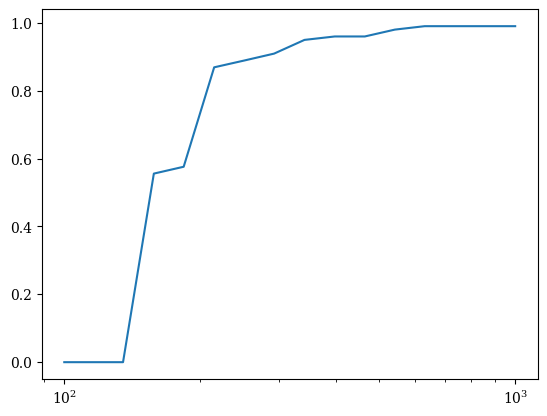

In [24]:
plt.semilogx(subSteps,aFracs)

In [41]:
subSteps[-9]

np.int64(292)

In [42]:
sim.analysis.acceptanceFraction(models[-9])

np.float64(0.9090909090909091)

In [31]:
correl = sim.distillation.correlStats(models[-1],burnIn=5,autocorrSkip=3)

configs:   0%|          | 0/32 [00:00<?, ?it/s]

In [32]:
sim.distillation.correlMassExtract(correl,fitT=[4,12],diagCov=True)

array([0.41841759, 0.00079913])